In [ ]:
!pip install yfinance

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 1. Select a stock and load historical data
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

# 2. Use features to predict the NEXT day's Close price
# We shift the Close price by -1 to align today's features with tomorrow's target
data['Target_Close'] = data['Close'].shift(-1)

# Drop rows with NaN (the last row won't have a next-day target)
data_clean = data.dropna().copy()

features = ['Open', 'High', 'Low', 'Volume']
X = data_clean[features]
y = data_clean['Target_Close']

display(data_clean.head())

/tmp/ipykernel_4320/623572915.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Target_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400,71.696640
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,72.267914
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200,71.928047
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000,73.085106
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200,74.637497


In [3]:
# Split data into training and testing sets (shuffling=False is often better for time series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print(f"Linear Regression R2: {r2_score(y_test, lr_preds):.4f}")
print(f"Random Forest R2: {r2_score(y_test, rf_preds):.4f}")

Linear Regression R2: 0.9579
Random Forest R2: 0.0869


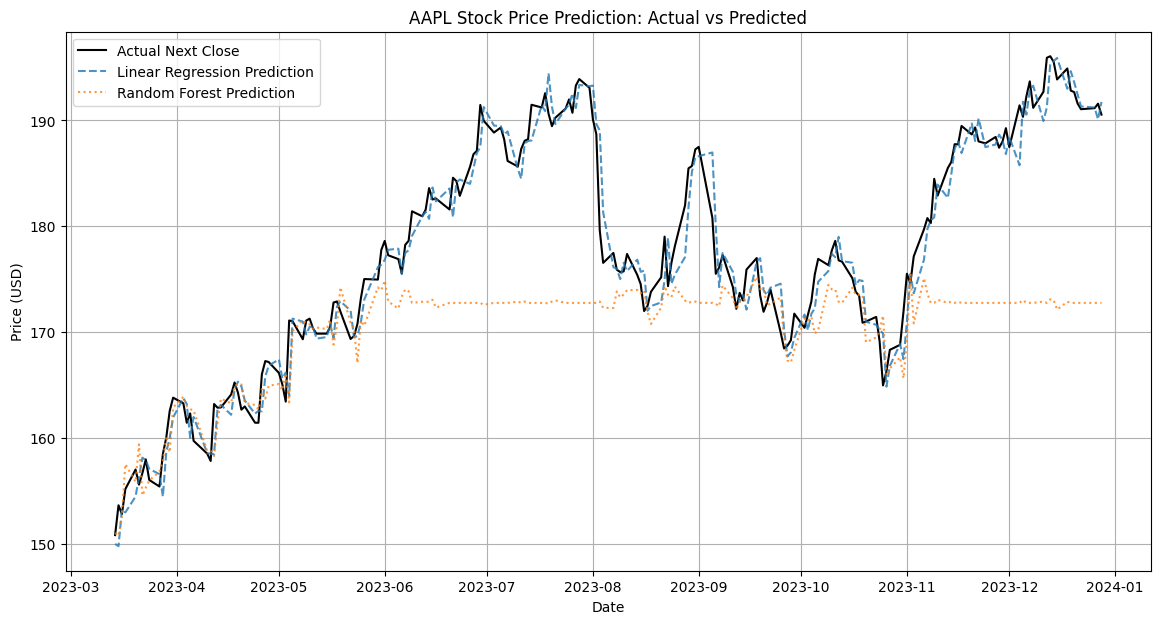

In [4]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Next Close', color='black', linewidth=1.5)
plt.plot(y_test.index, lr_preds, label='Linear Regression Prediction', linestyle='--', alpha=0.8)
plt.plot(y_test.index, rf_preds, label='Random Forest Prediction', linestyle=':', alpha=0.8)

plt.title(f'{ticker} Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()